In [1]:
import pandas as pd
import numpy as np

In [2]:
train=pd.read_parquet('../data/processData/train.parquet')
test=pd.read_parquet('../data/processData/test.parquet')

sample_sub=pd.read_csv('../data/rawData/sample_submission.csv')

In [3]:
import pickle
with open('../data/processData/id2type.pkl','rb') as f:
    id2type=pickle.load(f)
with open('../data/processData/type2id.pkl','rb') as f:
    type2id=pickle.load(f)


In [4]:
DO_LOCAL_VALIDATION = True

In [5]:
if DO_LOCAL_VALIDATION:
    seven_days=7*60*60*24
    # 取训练集的最后一周最后一周作为测试集，前三周为训练集
    train_cutoff=train.ts.max()-seven_days
    test=train[train.ts>train_cutoff]
    train=train[train.ts<=train_cutoff]

    # 去掉同时出现在train和test的session，防止信息泄露
    overlapping_sessions=set(train.session).intersection(set(test.session))
    test=test[~test.session.isin(overlapping_sessions)]


    new_test=[]
    data_to_calculate_validation_score=[]

    # 从测试集中划分为验证集
    for grp in test.groupby('session'):
        # 随机分割，grp是session所对的Dataframe
        cutoff=np.random.randint(1,grp[1].shape[0])
        new_test.append(grp[1].iloc[:cutoff])
        data_to_calculate_validation_score.append(grp[1].iloc[cutoff:])
    test=pd.concat(new_test).reset_index(drop=True)
    valid=pd.concat(data_to_calculate_validation_score).reset_index(drop=True)

    del new_test,data_to_calculate_validation_score

In [10]:
fraction=1/1000

# drop_duplicates(['session]) 对session相同的只保留第一个，sample随机抽样
session_train_set=train.drop_duplicates(['session']).sample(frac=fraction)['session']
subset_of_train=train[train.session.isin(session_train_set)]

session_test_set=test.drop_duplicates(['session']).sample(frac=fraction)['session']
subset_of_test=test[test.session.isin(session_test_set)]

# 提取出session作为索引，方便后续按照session做chunk遍历 [[]]方式取出的是Dataframe
subset_of_train.index=pd.MultiIndex.from_frame(subset_of_train[['session']])
subset_of_test.index=pd.MultiIndex.from_frame(subset_of_test[['session']])

In [12]:
all_consecutive_AIDs=[]
chunk_size=60_000

sessions=subset_of_train.session.unique()
for i in range(0,sessions.shape[0],chunk_size):
    # reset_index(drop=True)重建行索引，丢弃旧索引
    current_chunk=subset_of_train.loc[sessions[i]:sessions[min(sessions.shape[0]-1,i+chunk_size-1)]].reset_index(drop=True)
    # 取出每个session后30个，考虑性能和最近行为
    # as_index保持原有的索引，不用session做索引
    current_chunk=current_chunk.groupby('session',as_index=False).nth(list(range(-30,0))).reset_index(drop=True)
    # 按照session连接，对同一个session内的所有行（不区分属性）做笛卡尔积
    consecutive_AIDs=current_chunk.merge(current_chunk,on='session')
    # 排除自己和自己
    consecutive_AIDs=consecutive_AIDs[consecutive_AIDs.aid_x!=consecutive_AIDs.aid_y]
    # 通过时间戳(>=0)的方式保证两两算一次，不考虑顺序
    consecutive_AIDs['days_elapsed']=(consecutive_AIDs.ts_y-consecutive_AIDs.ts_x)/(24*60*60)
    consecutive_AIDs=consecutive_AIDs[(consecutive_AIDs.days_elapsed>=0) & (consecutive_AIDs.days_elapsed<=1)]

    all_consecutive_AIDs.append(consecutive_AIDs)

In [13]:
sessions=subset_of_test.session.unique()
for i in range(0,sessions.shape[0],chunk_size):
    # reset_index(drop=True)重建行索引，丢弃旧索引
    current_chunk=subset_of_test.loc[sessions[i]:sessions[min(sessions.shape[0]-1,i+chunk_size-1)]].reset_index(drop=True)
    # 取出每个session后30个，考虑性能和最近行为
    # as_index保持原有的索引，不用session做索引
    current_chunk=current_chunk.groupby('session',as_index=False).nth(list(range(-30,0))).reset_index(drop=True)
    # 按照session连接，对同一个session内的所有行（不区分属性）做笛卡尔积
    consecutive_AIDs=current_chunk.merge(current_chunk,on='session')
    # 排除自己和自己
    consecutive_AIDs=consecutive_AIDs[consecutive_AIDs.aid_x!=consecutive_AIDs.aid_y]
    # 通过时间戳(>=0)的方式保证两两算一次，不考虑顺序
    consecutive_AIDs['days_elapsed']=(consecutive_AIDs.ts_y-consecutive_AIDs.ts_x)/(24*60*60)
    consecutive_AIDs=consecutive_AIDs[(consecutive_AIDs.days_elapsed>=0) & (consecutive_AIDs.days_elapsed<=1)]

    all_consecutive_AIDs.append(consecutive_AIDs)

In [14]:
all_consecutive_AIDs=pd.concat(all_consecutive_AIDs).drop_duplicates(['session','aid_x','aid_y'])[['aid_x','aid_y']]

In [15]:
from collections import Counter,defaultdict

next_AIDs=defaultdict(Counter)
for row in all_consecutive_AIDs.itertuples():
    next_AIDs[row.aid_x][row.aid_y]+=1

In [16]:
len(next_AIDs)

46384

In [17]:
session_types=['clicks','carts','orders']
# 聚合session
test_session_AIDs=test.reset_index(drop=True).groupby('session')['aid'].apply(list)

labels=[]

for AIDs in test_session_AIDs:
    AIDs=list(dict.fromkeys(AIDs[::-1]))
    if len(AIDs)>=20:
        labels.append(AIDs[:20])
    else:
        counter=Counter()

        for AID in AIDs:
            subsequent_AID_counter=next_AIDs.get(AID)
            if subsequent_AID_counter:
                counter+=subsequent_AID_counter
        AIDs+=[AID for AID,_ in counter.most_common(40) if AID not in AIDs]
        labels.append(AIDs[:20])

(array([748219., 179519., 100713.,  77360.,  62515.,  54753.,  47374.,
         42816.,  37374., 450608.]),
 array([ 1. ,  2.9,  4.8,  6.7,  8.6, 10.5, 12.4, 14.3, 16.2, 18.1, 20. ]),
 <BarContainer object of 10 artists>)

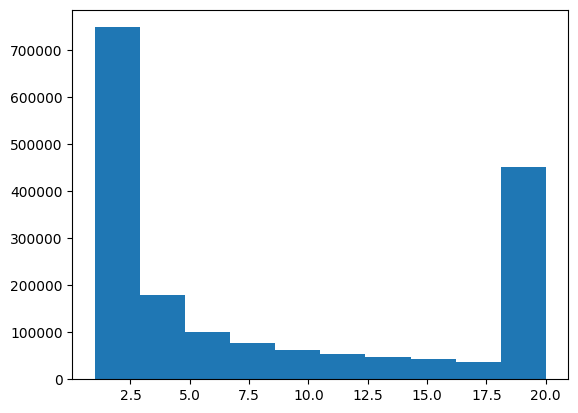

In [18]:
from matplotlib import pyplot as plt
plt.hist([len(l) for l in labels])

In [19]:
labels_as_strings=[' '.join([str(l) for l in lls]) for lls in labels] # 将预测的结果按转换为用空格分开的字符串

predictions=pd.DataFrame(data={'session_type':test_session_AIDs.index,'labels':labels_as_strings})
prediction_dfs=[]

for st in session_types:
    modified_predictions=predictions.copy()
    modified_predictions.session_type=modified_predictions.session_type.astype('str')+f'_{st}'
    prediction_dfs.append(modified_predictions)

submission=pd.concat(prediction_dfs).reset_index(drop=True)

In [21]:
submission.head()

,session_type,labels
0,11098528_clicks,1199737 1679529 1033148 11830 440367 1561739 1...
1,11098529_clicks,1105029
2,11098530_clicks,409236 264500 963957 364155 1603001 1180795 58...
3,11098531_clicks,1365569 1728212 1271998 624163 1553691 396199 ...
4,11098532_clicks,847816 1089 108125 461190 1308930 1550739 1596...


In [22]:
valid

,session,aid,ts,type
0,11098528,1199737,1661120104,1
1,11098528,990658,1661120599,2
2,11098528,1033148,1661120599,2
3,11098528,11830,1661120599,2
4,11098528,440367,1661120599,2
...,...,...,...,...
7683092,12899774,1399483,1661723976,0
7683093,12899775,1760714,1661723990,0
7683094,12899776,1737908,1661723987,0
7683095,12899777,384045,1661723986,0


In [23]:
if DO_LOCAL_VALIDATION:
    # 提取出session中原本的属性
    submission['session']=submission.session_type.apply(lambda x:int(x.split('_')[0]))
    submission['type']=submission.session_type.apply(lambda x:x.split('_')[1])
    submission.labels=submission.labels.apply(lambda x:[int(i) for i in x.split(' ')][:20])

    # 对series用map
    valid.type=valid.type.map(lambda idx:id2type[idx])
    # 一个以 (session, type) 为 MultiIndex的Series，值是该组内所有aid组成的list，即(session, type)所对的真实标签
    ground_truth=valid.groupby(['session','type'])['aid'].apply(list)
    # 重命名，将series转换为Dataframe，将索引变为列
    ground_truth=ground_truth.reset_index().rename(columns={'aid':'labels'})
    # str对series的元素做字符串操作，这里只保留click的第一个元素，比赛要求
    ground_truth.loc[ground_truth.type=='clicks','labels']=ground_truth.loc[ground_truth.type=='clicks','labels'].str[:1]

    # 合并，为预测的(session,type)匹配真实标签
    submission_with_gt=submission.merge(ground_truth[['session','type','labels']],how='left',on=['session','type'])
    # 删除没有真实标签的列
    submission_with_gt=submission_with_gt[~submission_with_gt.labels_y.isna()]
    submission_with_gt['hits']=submission_with_gt.apply(lambda df:len(set(df.labels_x).intersection(set(df.labels_y))),axis=1)

    # 对每个(session,type)统计真实标签数目，clip限制范围不超过20
    submission_with_gt['gt_count']=submission_with_gt.labels_y.str.len().clip(0,20)

    # 按照类型划分
    recall_per_type=submission_with_gt.groupby(['type'])['hits'].sum()/submission_with_gt.groupby(['type'])['gt_count'].sum()
    # 官方给的权重分数
    local_validation_score=(recall_per_type*pd.Series({'clicks':0.10,"carts":0.30,'orders':0.60})).sum()
    print(f'Local validation score: {local_validation_score}')
else:
    submission.to_csv('submission.csv', index=False)

Local validation score: 0.44999795188338354
